In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline


In [10]:
df_index=pd.read_csv('economic_index.csv')

In [11]:
df_index.head()

,Unnamed: 0,year,month,interest_rate,unemployment_rate,index_price
0,0,2017,12,2.75,5.3,1464
1,1,2017,11,2.50,5.3,1394
2,2,2017,10,2.50,5.3,1357
3,3,2017,9,2.50,5.3,1293
4,4,2017,8,2.50,5.4,1256


In [20]:
## drop unneccessary column
df_index.drop(columns=["Unnamed: 0","year","month"],axis=1,inplace=True)


In [21]:
df_index.head()

,interest_rate,unemployment_rate,index_price
0,2.75,5.3,1464
1,2.50,5.3,1394
2,2.50,5.3,1357
3,2.50,5.3,1293
4,2.50,5.4,1256


In [24]:
## check null value
df_index.isnull().sum()

interest_rate        0
unemployment_rate    0
index_price          0
dtype: int64

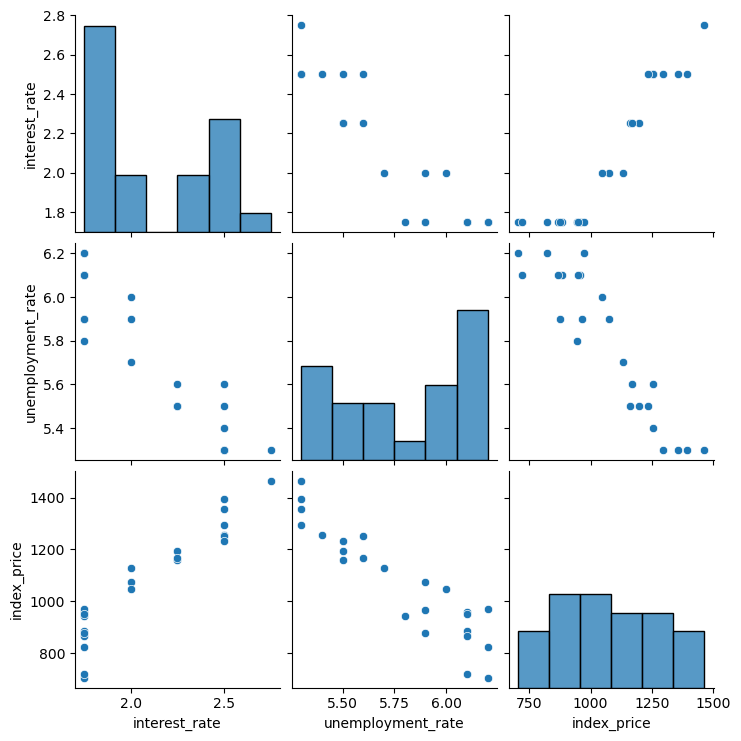

In [27]:
## lets d0 some viualization
import seaborn as sns
sns.pairplot(df_index)
plt.show()

In [28]:
df_index.corr()

,interest_rate,unemployment_rate,index_price
interest_rate,1.000000,-0.925814,0.935793
unemployment_rate,-0.925814,1.000000,-0.922338
index_price,0.935793,-0.922338,1.000000


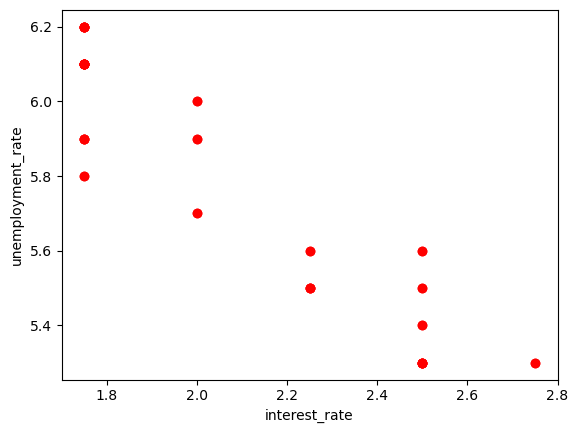

In [30]:
## visualiza the dotapoints more closely
plt.scatter(df_index['interest_rate'],df_index['unemployment_rate'],color='r')
plt.xlabel('interest_rate')
plt.ylabel('unemployment_rate')
plt.show()

In [32]:
## independent and dependent feature
X=df_index.iloc[:,:-1]
Y=df_index.iloc[:,-1]

In [33]:
X.head()

,interest_rate,unemployment_rate
0,2.75,5.3
1,2.50,5.3
2,2.50,5.3
3,2.50,5.3
4,2.50,5.4


In [34]:
Y.head()

0    1464
1    1394
2    1357
3    1293
4    1256
Name: index_price, dtype: int64

In [36]:
## train test split
from sklearn.model_selection import train_test_split
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.25,random_state=42)

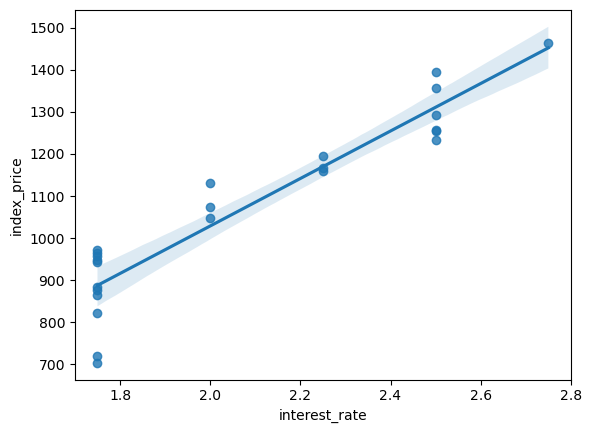

In [44]:
import seaborn as sns
sns.regplot(x=df_index['interest_rate'],y=df_index['index_price'])
plt.show()

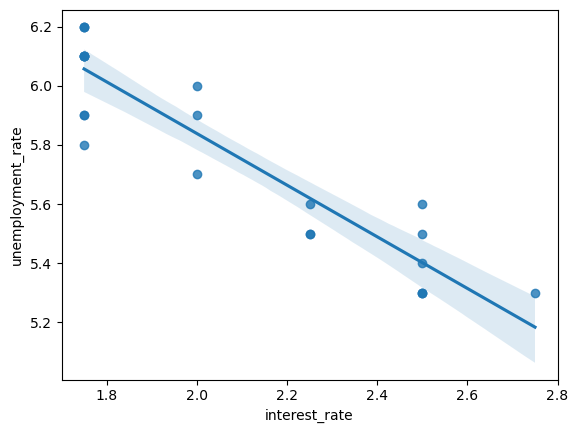

In [46]:
sns.regplot(x=df_index['interest_rate'],y=df_index['unemployment_rate'])
plt.show()

In [47]:
## standardlizcatin
from sklearn.preprocessing import StandardScaler

In [50]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
print(X_train,X_test)

[[-0.90115511  0.37908503]
 [ 1.31077107 -1.48187786]
 [-0.90115511  1.30956648]
 [ 1.31077107 -0.55139641]
 [ 1.31077107 -1.48187786]
 [-0.16384638  0.68924552]
 [-0.90115511  0.999406  ]
 [ 1.31077107 -1.48187786]
 [ 1.31077107 -1.17171738]
 [-0.90115511  1.30956648]
 [-0.90115511  0.999406  ]
 [-0.90115511  0.37908503]
 [-0.90115511  0.999406  ]
 [ 0.57346234 -0.8615569 ]
 [-0.16384638 -0.24123593]
 [-0.90115511  0.06892455]
 [-0.90115511  0.999406  ]
 [ 1.31077107 -0.8615569 ]] [[ 0.36115756 -0.82078268]
 [-1.08347268  1.33377186]
 [ 1.8057878  -1.43636969]
 [-1.08347268  1.02597835]
 [-0.36115756  0.41039134]
 [ 0.36115756 -0.51298918]]


In [52]:
## apply linear
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(X_train,Y_train)

LinearRegression()

In [55]:
## cross validation
from sklearn.model_selection import cross_val_score
validation_score=cross_val_score(regression,
                                 X_train,
                                 Y_train,
                                 scoring='neg_mean_squared_error',
                                 cv=3)

In [57]:
np.mean(validation_score)

np.float64(-5914.828180162389)

In [58]:
## predication
Y_pred=regression.predict(X_test)

In [59]:
Y_pred

array([1180.7466813 ,  802.74279699, 1379.83457045,  838.52599602,
        973.85313963, 1144.96348227])

In [60]:
## performace metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [61]:
mse=mean_squared_error(Y_test,Y_pred)
mae=mean_absolute_error(Y_test,Y_pred)
rmse=np.sqrt(mse)
print('mse:',mse)
print('mae:',mae)
print('rmse:',rmse)

mse: 8108.567426306604
mae: 73.80444932337097
rmse: 90.04758423359621


In [62]:
## R square
from sklearn.metrics import r2_score
score=r2_score(Y_test,Y_pred)
print(score)

0.7591371539010257


In [63]:
## Adjusted R square
1-(1-score)*(len(Y_test)-1)/(len(Y_test)-X_test.shape[1]-1)

0.5985619231683761

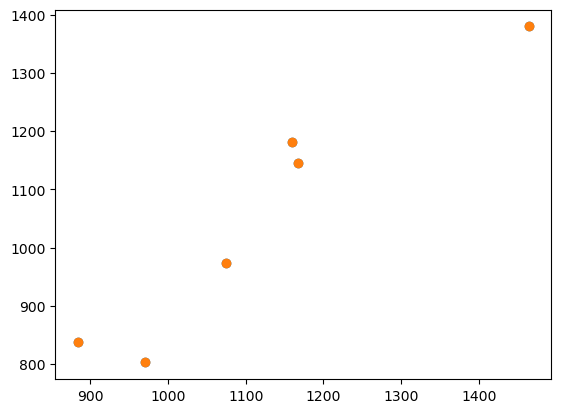

In [65]:
## Assumptions
plt.scatter(Y_test,Y_pred)
plt.show()

In [67]:
residuals = Y_test-Y_pred
print(residuals)

8     -21.746681
16    168.257203
0      84.165430
18     45.474004
11    101.146860
9      22.036518
Name: index_price, dtype: float64


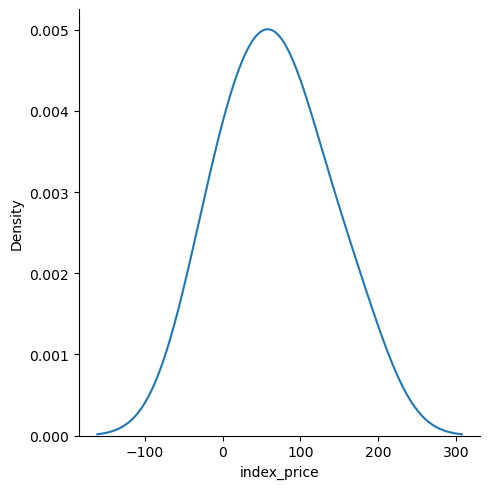

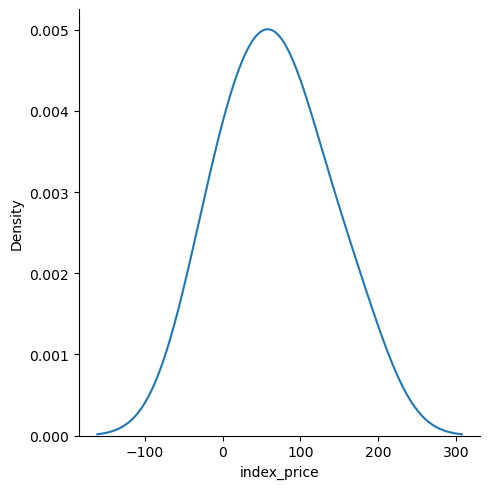

In [69]:
## plot this residuals
sns.displot(residuals,kind='kde')
plt.show()

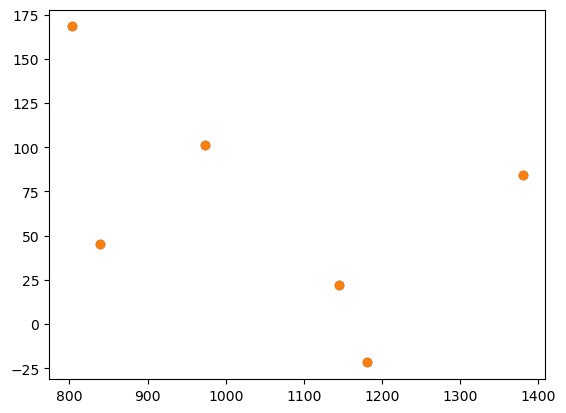

In [71]:
## scatter plot with respect to prediction and  residuals
plt.scatter(Y_pred,residuals)
plt.show()

In [72]:
## OLS linear
import statsmodels.api as sm
model=sm.OLS(Y_train,X_train).fit()
prediction=model.predict(X_test)
print(prediction)

[ 127.30223686 -250.70164745  326.390126   -214.91844842  -79.59130481
   91.51903783]


In [73]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:            index_price   R-squared (uncentered):                   0.035
Model:                            OLS   Adj. R-squared (uncentered):             -0.086
Method:                 Least Squares   F-statistic:                             0.2880
Date:                Thu, 05 Feb 2026   Prob (F-statistic):                       0.754
Time:                        21:11:46   Log-Likelihood:                         -150.85
No. Observations:                  18   AIC:                                      305.7
Df Residuals:                      16   BIC:                                      307.5
Df Model:                           2                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

C:\Users\nehas\anaconda3\Lib\site-packages\scipy\stats\_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=18 observations were given.
  return hypotest_fun_in(*args, **kwds)


In [79]:
## predition for new data
regression.predict(scaler.transform([[2.50,5.2]]))

array([669.58909669])

In [75]:
print(regression.coef_)

[  88.27275507 -116.25716066]
